# Šta je ušlo u trening

Prethodni notebook je gledao tabelu sa outfitima. Ovde gledamo šta je od te tabele stvarno stiglo
do modela.

Ni ovde ne otvaramo nijednu fotografiju. Sve dolazi iz tabele, iz zamrznutih podela i iz zapisa o
merenjima koja su sačuvana u `results/metrics`. Rezultat treninga se pojavi
samo jednom, kao poređenje uz podatke.

Zanima nas pet stvari. Od 44,096 redova u treningu završi petina i razlog nije u labelama. Boja je
najzastupljenije polje u odgovorima koje model uči, a boje u datasetu nema. Težine klasa se
računaju kao obrnuta frekvencija bez ikakvog ograničenja, pa klasa sa dve slike dobija težinu veću
od petsto. Najređe vrednosti nisu spojene nego su ušle u trening takve kakve jesu. I ocenjivač ne
uči na parovima koje je neko ocenio nego na kombinacijama koje smo sami sastavili.


## Učitavanje

Pored tabele i podela učitavamo i zapise o merenjima. To su obični JSON fajlovi koje skripte za
treniranje upišu kad završe, pa u njima stoji tačno ono sa čime je model radio.

Ako neki od tih fajlova nedostaje, učitavanje staje uz poruku koja kaže koja skripta ga pravi.


In [16]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from rmo import paths
from rmo.perception.cnn import CLASS_MAPS, HEAD_NAMES, class_weights, encode_frame
from rmo.splits import SPLIT_NAMES, load_split

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

PRESENT, MISSING, ACCENT = "#4c72b0", "#c44e52", "#dd8452"
FIGURE_DIR = paths.ensure_dir(paths.repo_root() / "results" / "figures")

BUILDERS = {
    "smolvlm_preflight": (
        "python scripts/preflight_smolvlm_dataset.py "
        "--json results/metrics/smolvlm_preflight.json"
    ),
    "perception_cnn_train": "python scripts/train_cnn.py",
    "scoring_missingness_guard": "python scripts/train_scoring.py --guard",
    "scoring_logreg_coefficients": "python scripts/train_scoring.py --fit",
    "scoring_learned_scorer_v1_test": (
        "python -m rmo.eval.scoring_eval --scorer learned_scorer_v1 --split test"
    ),
}


def save_figure(fig, name):
    """Upisuje nacrtani grafikon u direktorijum sa figurama."""
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


class MissingArtifact(RuntimeError):
    """Podiže se kada tabela ili zapis o merenju nisu napravljeni u ovom checkout-u."""


def load_outfits():
    """Učitava tabelu sa outfitima ili objašnjava kako da se napravi."""
    table_path = paths.processed_dir() / "outfits.parquet"
    if not table_path.is_file():
        raise MissingArtifact(
            f"Nema tabele sa outfitima na putanji {table_path}.\n"
            "Napravi je sa:\n"
            "    python scripts/download_data.py --labels-only --parsing --from <staging>\n"
            "    python scripts/build_dataset.py"
        )
    return pd.read_parquet(table_path)


def load_metric(name):
    """Učitava zapis o merenju ili kaže koja ga skripta pravi."""
    record_path = paths.metrics_dir() / f"{name}.json"
    if not record_path.is_file():
        raise MissingArtifact(
            f"Nema zapisa {record_path}.\nNapravi ga sa:\n    {BUILDERS[name]}"
        )
    return json.loads(record_path.read_text(encoding="utf-8"))


outfits = load_outfits()
splits = {name: load_split(name) for name in SPLIT_NAMES}
preflight = load_metric("smolvlm_preflight")
cnn_run = load_metric("perception_cnn_train")
guard = load_metric("scoring_missingness_guard")
coefficients = load_metric("scoring_logreg_coefficients")
scoring_test = load_metric("scoring_learned_scorer_v1_test")

len(outfits), {name: len(ids) for name, ids in splits.items()}


(44096, {'train': 9071, 'val': 1815, 'test': 1815})

## Od tabele do trening skupa

Tabela ima 44,096 redova, a trening skup 9,071 sliku. Razlika je velika, pa vredi videti gde se
tačno gubi. Svaki korak ispod izbacuje slike iz jednog određenog razloga, a poslednja dva broja
dolaze iz zamrznutih podela.


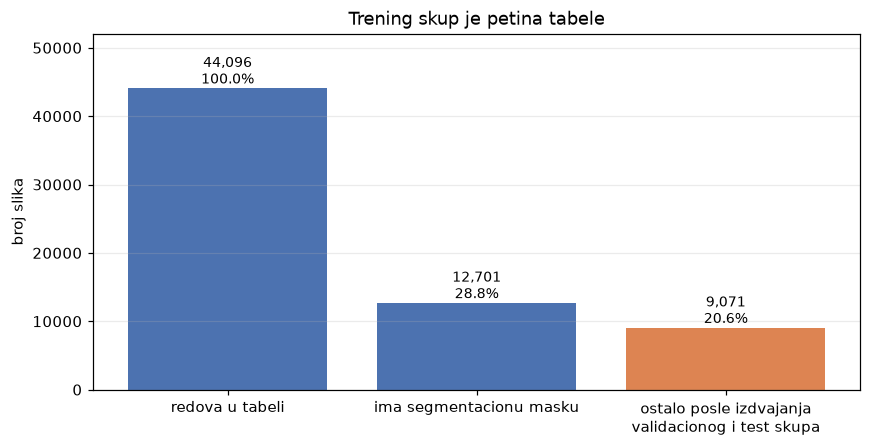

In [17]:
full_body = outfits.loc[outfits["is_full_body"]]
stages = pd.Series(
    {
        "redova u tabeli": len(outfits),
        "ima segmentacionu masku": len(full_body),
        "ostalo posle izdvajanja\nvalidacionog i test skupa": len(splits["train"]),
    }
)

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(stages.index, stages.to_numpy(), color=[PRESENT, PRESENT, ACCENT])
for bar, value in zip(bars, stages.to_numpy()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}\n{value / len(outfits):.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylabel("broj slika")
ax.set_title("Trening skup je petina tabele")
ax.grid(axis="x", visible=False)
ax.margins(y=0.18)
save_figure(fig, "training_funnel")


In [18]:
train_rows = outfits.loc[outfits["image_id"].isin(splits["train"])]
built = preflight["splits"]["train"]

funnel = pd.DataFrame(
    {
        "vrednost": [
            f"{len(outfits):,}",
            f"{int((~outfits['has_shape']).sum()):,}",
            f"{int((~full_body['has_shape']).sum()):,}",
            f"{int((~train_rows['has_shape']).sum()):,}",
            f"{built['requested']:,} traženo, {built['built']:,} napravljeno",
            f"{sum(built['errors'].values())}",
        ]
    },
    index=[
        "redova u tabeli",
        "bez shape anotacije u celoj tabeli",
        "bez shape anotacije među slikama sa maskom",
        "bez shape anotacije u trening skupu",
        "primera napravljeno od trening skupa",
        "primera koji nisu mogli da se naprave",
    ],
)
funnel


,vrednost
redova u tabeli,"44,096"
bez shape anotacije u celoj tabeli,"1,552"
bez shape anotacije među slikama sa maskom,7
bez shape anotacije u trening skupu,4
primera napravljeno od trening skupa,"9,071 traženo, 9,071 napravljeno"
primera koji nisu mogli da se naprave,0


**Zaključak.** Od 44,096 redova trening dobija 9,071, odnosno 20.6%. Ceo gubitak pravi jedan
jedini uslov, a to je postojanje segmentacione maske. Fabric i pattern labele imamo za svaku sliku
u tabeli, ali bez maske ne znamo koji piksel pripada kom odevnom predmetu, pa ne možemo ni da
izmerimo boju ni da kažemo šta se sve na slici nalazi.

## Od čega se sastoji tačan odgovor

Model za percepciju uči da za sliku ispiše listu odevnih predmeta i njihove osobine. Zapis o
pripremi podataka broji svako polje koje je u tom odgovoru popunjeno, razvrstano po delu odeće.
Kada se to sabere, vidi se da svi delovi odeće nisu ni izbliza jednako opisani.


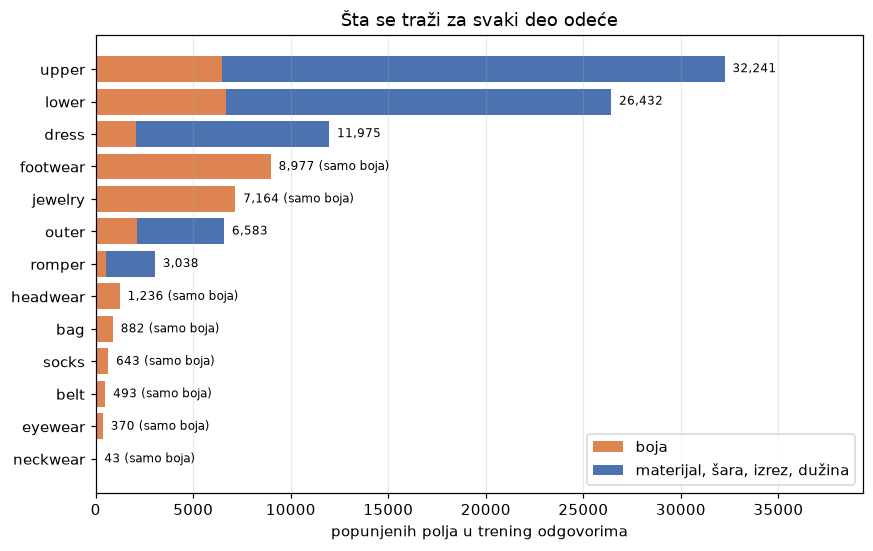

In [19]:
presence = pd.Series(built["field_presence"])
slot_names = [key.split(".", 1)[0] for key in presence.index]
field_names = [key.split(".", 1)[1] for key in presence.index]
fields = pd.DataFrame({"slot": slot_names, "field": field_names, "count": presence.to_numpy()})
by_slot = fields.pivot_table(index="slot", columns="field", values="count", fill_value=0)
by_slot = by_slot.loc[by_slot.sum(axis=1).sort_values().index]

other_fields = [name for name in by_slot.columns if name != "color"]
colour_only = by_slot.index[by_slot[other_fields].sum(axis=1) == 0]

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.barh(by_slot.index, by_slot["color"], color=ACCENT, label="boja")
ax.barh(
    by_slot.index,
    by_slot[other_fields].sum(axis=1),
    left=by_slot["color"],
    color=PRESENT,
    label="materijal, šara, izrez, dužina",
)
for slot, total in by_slot.sum(axis=1).items():
    mark = " (samo boja)" if slot in colour_only else ""
    ax.text(total + 400, slot, f"{int(total):,}{mark}", va="center", fontsize=8)
ax.set_xlabel("popunjenih polja u trening odgovorima")
ax.set_title("Šta se traži za svaki deo odeće")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
ax.margins(x=0.22)
save_figure(fig, "training_target_fields")


In [20]:
per_field = fields.groupby("field")["count"].sum().sort_values(ascending=False).to_frame("polja")
per_field["udeo svih polja"] = (per_field["polja"] / per_field["polja"].sum()).map("{:.1%}".format)
per_field["izvor"] = [
    "izmereno iz piksela" if name == "color" else "labela iz dataseta" for name in per_field.index
]

shape_of_answer = pd.DataFrame(
    {
        "vrednost": [
            f"{int(by_slot['color'].sum()):,}",
            f"{int(by_slot.loc[colour_only, 'color'].sum()):,}",
            f"{built['garments_per_image']['median']} (najviše {built['garments_per_image']['max']})",
            f"{built['target_characters']['median']} (najviše {built['target_characters']['max']})",
        ]
    },
    index=[
        "odevnih predmeta u trening odgovorima",
        "predmeta za koje se traži samo boja",
        "predmeta po slici, srednja vrednost",
        "znakova u odgovoru, srednja vrednost",
    ],
)
display(per_field, shape_of_answer)


,polja,udeo svih polja,izvor
field,,,
color,37651,37.6%,izmereno iz piksela
fabric,17709,17.7%,labela iz dataseta
pattern,17603,17.6%,labela iz dataseta
neckline,9066,9.1%,labela iz dataseta
sleeve_length,9066,9.1%,labela iz dataseta
length,8982,9.0%,labela iz dataseta


,vrednost
odevnih predmeta u trening odgovorima,"37,651"
predmeta za koje se traži samo boja,"19,808"
"predmeta po slici, srednja vrednost",4 (najviše 8)
"znakova u odgovoru, srednja vrednost",247 (najviše 406)


**Zaključak.** Trening odgovori pokrivaju 37,651 odevni predmet i u njima je popunjeno 100,077
polja. Od toga je 37,651 polje boja, dakle 37.6%, što je više nego materijal i šara zajedno.
Prethodni notebook je pokazao da boje u datasetu nema nigde, ni u labelama ni u opisima. Ono što
model najviše vežba da napiše je zato merenje koje smo sami izračunali iz piksela, a ne nešto što
je čovek obeležio.

Za osam od trinaest delova odeće boja je jedino što se uopšte traži. To su torbe, kaiševi,
naočare, obuća, kape, nakit, marame i čarape, zajedno 19,808 predmeta ili nešto više od polovine.
Za njih model ne uči nijedan atribut osim boje, jer dataset za te delove odeće nema šta drugo da
ponudi.

Odgovor je uz to kratak i strogo oblikovan. Srednja vrednost je četiri predmeta i 247 znakova, a
najduži odgovor ima 406 znakova. Kada se to spoji sa prethodnim, ispada da fine-tuning najviše
vežba dve stvari, oblik odgovora i imenovanje boje. Oba se uče brzo, a nijedno ne govori mnogo o
prepoznavanju odeće.


## Koliko vredi jedna slika

Konvolutivna mreža ima devet izlaza i svaki uči svoju kolonu tabele. Pošto su klase jako
neravnomerne, svaka dobija težinu obrnuto srazmernu broju slika na kojima se javlja. Taj postupak
je u kodu napisan bez ikakvog ograničenja odozgo, pa ima smisla pogledati koliko te težine zaista
budu velike.

Težine računamo istom funkcijom koju koristi i skripta za treniranje, nad istim trening splitom.


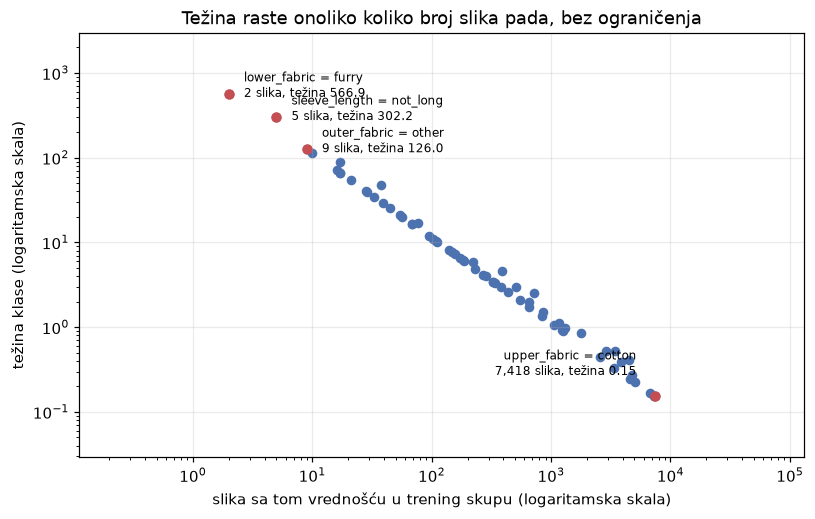

In [21]:
targets, supervised = encode_frame(train_rows.sort_values("image_id"))
weights = class_weights(targets, supervised)

rows = []
for index, head in enumerate(HEAD_NAMES):
    counts = np.bincount(targets[supervised[:, index], index], minlength=len(CLASS_MAPS[head]))
    for position, value in enumerate(CLASS_MAPS[head]):
        rows.append(
            {
                "head": head,
                "value": value,
                "slika": int(counts[position]),
                "težina": weights[head][position],
            }
        )
classes = pd.DataFrame(rows)
extremes = pd.concat([classes.nlargest(3, "težina"), classes.nsmallest(1, "težina")])
offsets = [(10, -2), (10, -2), (10, -2), (-12, 14)]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(classes["slika"], classes["težina"], color=PRESENT, s=28)
ax.scatter(extremes["slika"], extremes["težina"], color=MISSING, s=34)
for offset, (_, row) in zip(offsets, extremes.iterrows()):
    weight = row["težina"]
    shown = f"{weight:.2f}" if weight < 1 else f"{weight:.1f}"
    ax.annotate(
        f"{row['head']} = {row['value']}\n{row['slika']:,} slika, težina {shown}",
        (row["slika"], weight),
        textcoords="offset points",
        xytext=offset,
        ha="right" if offset[0] < 0 else "left",
        fontsize=8,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("slika sa tom vrednošću u trening skupu (logaritamska skala)")
ax.set_ylabel("težina klase (logaritamska skala)")
ax.set_title("Težina raste onoliko koliko broj slika pada, bez ograničenja")
ax.margins(x=0.35, y=0.2)
save_figure(fig, "class_weight_spread")


In [22]:
per_head = cnn_run["metrics"]["per_head"]
by_head = classes.groupby("head")
heads = pd.DataFrame(
    {
        "najmanja klasa": by_head["slika"].min(),
        "klasa ispod 50 slika": by_head["slika"].apply(lambda column: int((column < 50).sum())),
        "odnos najveće i najmanje težine": (by_head["težina"].max() / by_head["težina"].min())
        .round()
        .astype(int),
        "macro-F1 na validaciji": pd.Series(
            {name: values["macro_f1"] for name, values in per_head.items()}
        ),
    }
).sort_values("macro-F1 na validaciji")
heads.index.name = "izlaz mreže"
heads


,najmanja klasa,klasa ispod 50 slika,odnos najveće i najmanje težine,macro-F1 na validaciji
izlaz mreže,,,,
upper_fabric,10,3,742,0.284789
lower_fabric,2,4,2286,0.325212
outer_pattern,17,3,429,0.356845
lower_pattern,28,1,241,0.391217
neckline,77,0,62,0.400368
upper_pattern,69,0,73,0.446719
outer_fabric,9,1,810,0.517100
sleeve_length,5,2,772,0.565439
lower_length,38,1,118,0.642864


**Zaključak.** Prethodni notebook je upozorio da obrnuta frekvencija bez ograničenja može da da
besmislene težine. Tako je i ispalo. Materijal `furry` na donjem delu odeće ima dve slike u
trening skupu i težinu 566.9, a `cotton` na gornjem delu ima 7,418 slika i težinu 0.15. Te dve
slike zato u funkciji greške vrede kao 3,709 slika sa pamukom.

Kod izlaza za materijal donjeg dela odeće najveća i najmanja težina se razlikuju 2,286 puta. Kod
izreza, gde nema tako praznih klasa, razlika je 62 puta.

Veza sa rezultatom postoji ali nije prosta. Tri izlaza koja imaju tri ili više klasa sa manje od
pedeset slika su upravo tri najslabija, materijal gornjeg dela, materijal donjeg dela i šara
spoljnog sloja. Sva tri su ispod macro-F1 od 0.36, dok najbolji izlaz za dužinu donjeg dela ima
0.64 i samo jednu tako praznu klasu. Prazne klase dakle ne objašnjavaju sve, ali se svaka nalazi
tamo gde je rezultat loš.

Nijedan izlaz nije ostao potpuno bez podataka, pa je mreža stvarno trenirala svih devet.


## Vrednosti koje su prošle u trening

Ovde gledamo koje su vrednosti stigle do treninga i sa koliko
primera. Brojimo pojave u trening odgovorima, a ne slike, jer se jedan predmet javlja jednom po
slici.


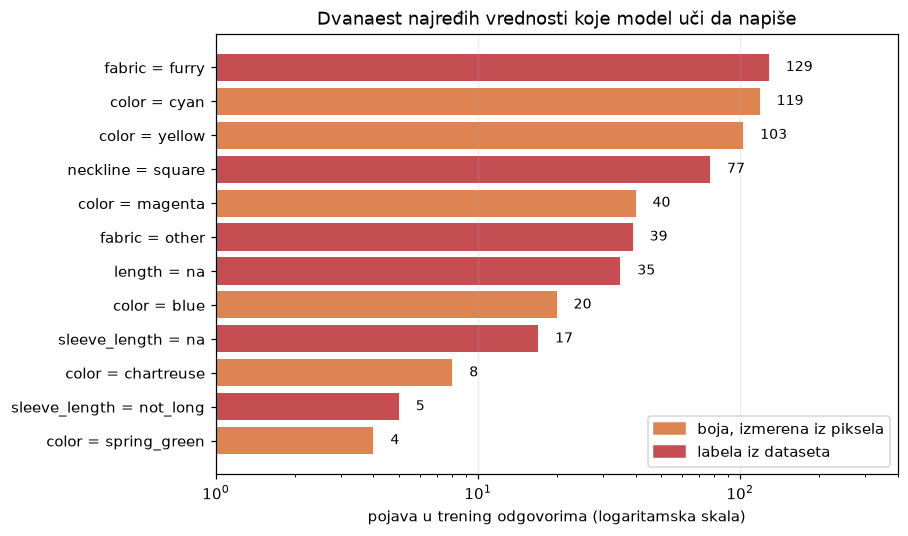

In [27]:
train_values = pd.DataFrame(
    [
        {"field": field, "label": f"{field} = {value}", "pojava": count}
        for field, counter in built["field_values"].items()
        for value, count in counter.items()
    ]
)
rarest = train_values.nsmallest(12, "pojava").sort_values("pojava")

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(
    rarest["label"],
    rarest["pojava"],
    color=[ACCENT if name == "color" else MISSING for name in rarest["field"]],
)
for label, value in zip(rarest["label"], rarest["pojava"]):
    ax.text(value * 1.16, label, f"{value:,}", va="center", fontsize=9)
ax.set_xscale("log")
ax.set_xlim(1, 400)
ax.set_xlabel("pojava u trening odgovorima (logaritamska skala)")
ax.set_title("Dvanaest najređih vrednosti koje model uči da napiše")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=ACCENT, label="boja, izmerena iz piksela"),
        plt.Rectangle((0, 0), 1, 1, color=MISSING, label="labela iz dataseta"),
    ],
    loc="lower right",
)
ax.grid(axis="y", visible=False)
save_figure(fig, "rare_training_values")


In [28]:
unseen = []
for field, counter in preflight["splits"]["val"]["field_values"].items():
    for value, count in counter.items():
        if value not in built["field_values"][field]:
            unseen.append({"polje": field, "vrednost": value, "pojava u validaciji": count})

display(
    pd.DataFrame(unseen) if unseen else "Svaka vrednost iz validacije postoji i u treningu.",
    pd.Series(preflight["coverage_warnings"], name="upozorenja pri pripremi").to_frame(),
)


,polje,vrednost,pojava u validaciji
0,color,violet,1


,upozorenja pri pripremi
0,val has derived color value(s) absent from tra...


**Zaključak.** Najređe vrednosti su ušle u
trening takve kakve jesu. Boja `spring_green` se javlja četiri puta, `chartreuse` osam, a dužina
rukava `not_long` pet puta. Tri od šesnaest boja imaju najviše dvadeset primera.

Zanimljivo je da se najređe vrednosti više ne poklapaju sa onima iz prethodnog notebooka. Tamo je
najređa bila `eyeglasses` sa četiri slike, ali naočare nisu deo onoga što model opisuje, pa te
klase ovde nema. Umesto nje je pola najređe dvanaestorke sada boja, a boje su izvedene iz piksela
i nisu se videle dok smo gledali samo labele.



## Trening podaci koje smo sami napravili

Ocenjivač uči da razlikuje dobre kombinacije odeće od loših, ali niko u datasetu nije rekao koja
je kombinacija loša. Zato se od svakog outfita pravi jedan pozitivan i dva negativna primera.
Negativi nastaju tako što se jedan ili svi delovi odeće zamene delovima iz drugog outfita, uvek iz
druge grupe proizvoda.

Koliko takvih primera je stvarno napravljeno vidi se iz zapisa o treniranju i o merenju.


,slika u splitu,napravljenih primera,očekivano bez gubitka,izgubljeno
train,9071,27210,27213,3
val,1815,5444,5445,1


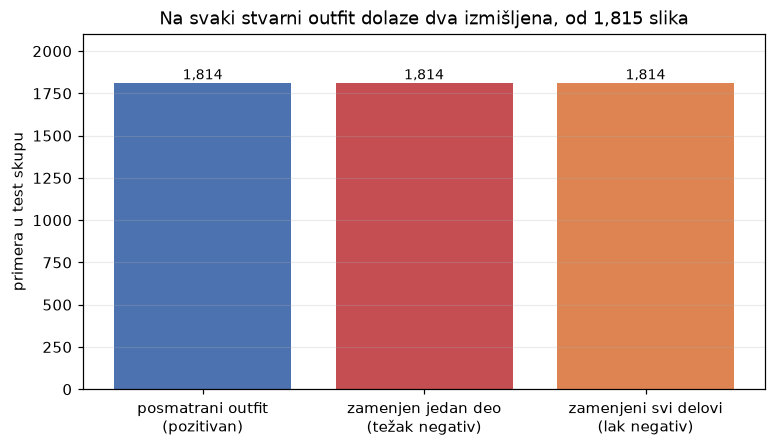

In [25]:
missingness = guard["metrics"]["missingness"]
built_records = {"train": missingness["n_fit"], "val": missingness["n_evaluated"]}
accounting = pd.DataFrame(
    {
        "slika u splitu": {name: len(splits[name]) for name in built_records},
        "napravljenih primera": built_records,
    }
)
accounting["očekivano bez gubitka"] = accounting["slika u splitu"] * 3
accounting["izgubljeno"] = accounting["očekivano bez gubitka"] - accounting["napravljenih primera"]

kinds = scoring_test["metrics"]["distribution_fit"]
mix = pd.Series(
    {
        "posmatrani outfit\n(pozitivan)": kinds["n_observed"],
        "zamenjen jedan deo\n(težak negativ)": kinds["n_hard"],
        "zamenjeni svi delovi\n(lak negativ)": kinds["n_easy"],
    }
)

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(mix.index, mix.to_numpy(), color=[PRESENT, MISSING, ACCENT])
for bar, value in zip(bars, mix.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("primera u test skupu")
ax.set_title(f"Na svaki stvarni outfit dolaze dva izmišljena, od {len(splits['test']):,} slika")
ax.grid(axis="x", visible=False)
ax.margins(y=0.16)
save_figure(fig, "scoring_pair_mix")
display(accounting)


In [26]:
feature_names = coefficients["feature_names"]
feature_groups = pd.Series(
    [name.split("__")[1] if "__" in name else name for name in feature_names]
).value_counts()

setup = pd.DataFrame(
    {
        "vrednost": [
            f"{len(feature_names):,}",
            f"{int(feature_groups.get('color', 0)):,}",
            f"{missingness['n_indicators']}",
            f"{missingness['auc']:.3f} uz prag {missingness['threshold']}, {missingness['status']}",
        ]
    },
    index=[
        "obeležja koja ocenjivač koristi",
        "obeležja koja imenuju boju predmeta",
        "indikatora nedostajućih vrednosti u kontroli",
        "koliko se outfit prepoznaje samo po tome šta nedostaje",
    ],
)
setup


,vrednost
obeležja koja ocenjivač koristi,372
obeležja koja imenuju boju predmeta,95
indikatora nedostajućih vrednosti u kontroli,52
koliko se outfit prepoznaje samo po tome šta nedostaje,"0.514 uz prag 0.6, PASS"


**Zaključak.** Pravljenje primera gotovo ništa ne gubi. Od 9,071 trening slike nastalo je 27,210
primera umesto 27,213, dakle nedostaju tri. U validaciji nedostaje jedan primer od 5,445. U test
skupu su sve tri vrste jednake i imaju po 1,814 primera, pa se tamo vidi da je tačno jedan outfit
ostao bez ijednog primera.

Bitniji je odnos, jedan stvarni outfit prema dva sastavljena. Labela koju ocenjivač uči zato ne
znači dobro naspram loše nego viđeno naspram sklopljeno. Model koji to nauči prepoznaje da li je
kombinacija onakva kakva se u datasetu javlja, a ne da li lepo izgleda.

Kontrola koja je uz to urađena ima smisla i prošla je. Ona proverava da li se pozitiv može
pogoditi samo po tome koja obeležja nedostaju, jer sastavljeni outfiti lako dobiju drugačiji
raspored praznina. Rezultat je 0.514 uz prag 0.6, dakle skoro nasumično. To znači da rezultat
ocenjivača ne dolazi iz te rupe, nego iz samih obeležja. Od 372 obeležja njih 95 imenuje boju,
koje opet nije iz dataseta.


## Šta se iz ovoga vidi

Trening je dobio 9,071 sliku, petinu tabele, i sve što je izgubljeno otišlo je zbog jednog uslova,
a to je postojanje segmentacione maske. Labele nisu bile usko grlo.

Boja se provlači kroz ceo projekat. Ona je 37.6% svih popunjenih polja u odgovorima koje model
uči, jedino što se traži za osam od trinaest delova odeće, i 95 od 372 obeležja kod ocenjivača. A
boja je jedino polje u opisu outfita koje ne dolazi iz dataseta nego iz naših piksela. Rezultati
koji izgledaju dobro zato dobrim delom govore o tome koliko dobro model prepisuje naše merenje.

Dve preporuke iz prethodnog notebooka nisu sprovedene. Retke klase nisu spojene, pa u trening
ulaze vrednosti sa četiri i pet pojava, a težine klasa se i dalje računaju kao obrnuta frekvencija
bez ograničenja, pa klasa sa dve slike vredi kao 3,709 slika sa pamukom. Tri izlaza sa najviše
takvih klasa su i tri najslabija.

Ocenjivač uči na podacima koje smo sami napravili, dva izmišljena outfita na svaki stvarni. Dok neko ne oceni prave kombinacije, ni najbolji rezultat tu ne meri ukus.
